# CA5 Pepper Spiciness Prediction 

## Import Libraries 

In [1]:
# import libraries for plotting and data manipulation
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np

# import classifiers 
from sklearn.linear_model import Ridge, Lasso, RANSACRegressor, ElasticNet 
from sklearn.ensemble import RandomForestRegressor, AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier

# import model selection and preprocessing tools 
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, f1_score
from sklearn.impute import SimpleImputer


## Load the Data 

In [2]:
train_data = pd.read_csv('/Users/tuva/Documents/DAT200/CAs/CA5/train.csv') 
test_data= pd.read_csv('/Users/tuva/Documents/DAT200/CAs/CA5/test.csv') 

## Data Exploration

### Look at the shape of the data 

In [3]:
train_data.shape, test_data.shape

((1000, 15), (800, 14))

The train and test data includes 14 features (plus one target variable in the test data). 

The training data has 1000 samples. 

The test data has 800 samples.

### Overview of the Data 

In [4]:
train_data.head() 

,Length (cm),Width (cm),Weight (g),Pericarp Thickness (mm),Seed Count,Capsaicin Content,Vitamin C Content (mg),Sugar Content,Moisture Content,Firmness,color,Harvest Time,Average Daily Temperature During Growth (celcius),Average Temperature During Storage (celcius),Scoville Heat Units (SHU)
0,17.37,5.42,94.30,4.90,193.93,3.21,173.59,6.15,88.59,3.40,red,Midday,8.68,5-6,0.00
1,27.78,4.75,262.71,6.56,186.29,8.19,100.41,2.36,111.20,5.45,green,Midday,22.44,NaN,0.00
2,6.17,3.51,66.72,7.96,298.81,4.69,125.91,6.75,72.98,2.77,red,Midday,24.99,NaN,455995.06
3,6.12,6.07,51.24,4.57,39.36,2.76,143.54,5.93,63.93,1.62,yellow,Midday,13.05,NaN,0.00
4,28.58,4.84,166.51,3.07,194.07,7.01,193.76,2.85,88.19,3.99,red,Midday,27.08,NaN,0.00


The data includes the following features: 

- Length (cm) 
- Width (cm) 
- Weight (g) 
- Pericarp Thickness (mm) 
- Seed count 
- Capsaicin Content 
- Vitamin C Content (mg) 
- Sugar Content 
- Moisture Content 
- Firmness 
- Color
- Harvest Time 
- Average Daily Temperature During Growth (celcius) 
- Average Temperature During Storage (celcius) 

The target variable is: 

- Scoville Heat Units (SHU) 

In [5]:
test_data.head()

,Length (cm),Width (cm),Weight (g),Pericarp Thickness (mm),Seed Count,Capsaicin Content,Vitamin C Content (mg),Sugar Content,Moisture Content,Firmness,color,Harvest Time,Average Daily Temperature During Growth (celcius),Average Temperature During Storage (celcius)
0,20.60,6.92,90.98,3.55,2.25,0.89,128.00,6.64,75.72,4.33,red,Midday,28.05,7-8
1,9.38,11.84,130.67,0.51,2.92,4.86,158.31,1.45,121.15,3.95,yellow,Midday,18.89,NaN
2,7.65,3.87,78.76,8.88,125.27,3.55,96.85,3.80,133.85,3.35,yellow,Midday,15.87,NaN
3,9.04,7.89,149.76,5.26,284.68,3.86,231.46,4.99,109.73,5.50,red,Midday,19.51,NaN
4,9.80,6.65,127.25,1.38,126.19,12.60,174.90,5.33,104.12,1.61,red,Midday,23.61,NaN


### Visualize feature distributions 

/var/folders/q0/1x8dgnnx3k1d4qfhdrmfxvlh0000gn/T/ipykernel_8089/1905107499.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/q0/1x8dgnnx3k1d4qfhdrmfxvlh0000gn/T/ipykernel_8089/1905107499.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/q0/1x8dgnnx3k1d4qfhdrmfxvlh0000gn/T/ipykernel_8089/1905107499.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


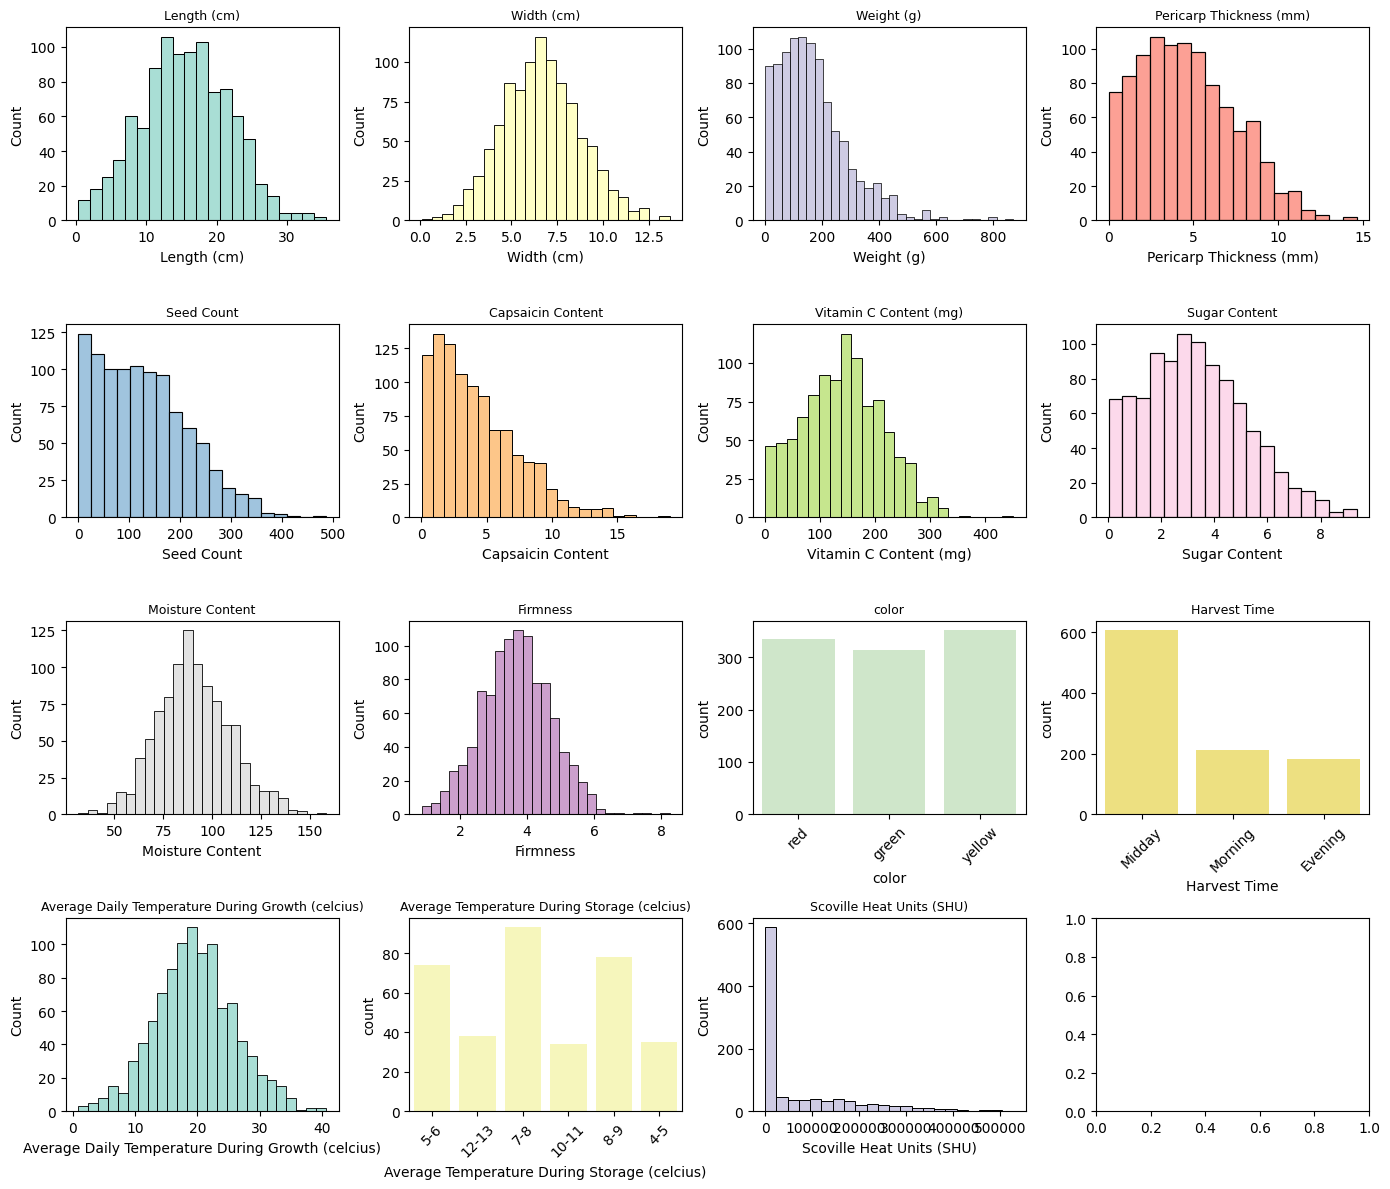

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
axes = axes.flatten()

columns = train_data.columns.to_list()
colors = sns.color_palette('Set3', n_colors=len(columns))

for i, col in enumerate(columns):
    ax = axes[i]
    try:
        if train_data[col].dtype == 'object':  # Kategorisk
            sns.countplot(x=train_data[col], ax=ax, color=colors[i])
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        else:  # Numerisk
            sns.histplot(train_data[col], ax=ax, color=colors[i])
        ax.set_title(col, fontsize=9)
    except Exception as e:
        ax.set_visible(False)
        print(f"Kunne ikke plotte '{col}': {e}")

plt.tight_layout()
plt.show()


### Perform Descriptive Statistics 

In [7]:
train_data.describe() 

,Length (cm),Width (cm),Weight (g),Pericarp Thickness (mm),Seed Count,Capsaicin Content,Vitamin C Content (mg),Sugar Content,Moisture Content,Firmness,Average Daily Temperature During Growth (celcius),Scoville Heat Units (SHU)
count,999.000000,999.000000,999.000000,998.000000,999.000000,999.000000,1000.000000,999.000000,1000.000000,999.000000,1000.000000,1000.000000
mean,15.574675,6.641572,169.346406,4.619499,128.731301,4.215385,142.035180,3.283534,90.878380,3.679179,19.641960,70941.260020
std,6.267303,2.139023,123.779026,2.829503,87.270366,3.163125,72.246142,1.938264,18.724314,1.034726,6.436255,108149.917069
min,0.300000,0.100000,0.560000,0.000000,0.040000,0.010000,0.950000,0.010000,31.400000,0.850000,0.840000,0.000000
25%,11.290000,5.140000,79.020000,2.400000,55.390000,1.710000,92.290000,1.865000,78.585000,2.980000,15.397500,0.000000
50%,15.520000,6.600000,147.230000,4.280000,119.490000,3.590000,141.730000,3.140000,89.690000,3.660000,19.495000,0.000000
75%,19.900000,8.045000,227.625000,6.560000,186.845000,6.115000,192.720000,4.555000,103.200000,4.375000,23.530000,121349.617500
max,35.570000,13.620000,869.970000,14.630000,487.260000,19.020000,450.290000,9.360000,158.300000,8.250000,40.700000,527639.860000


### Visualizing feature correlations 

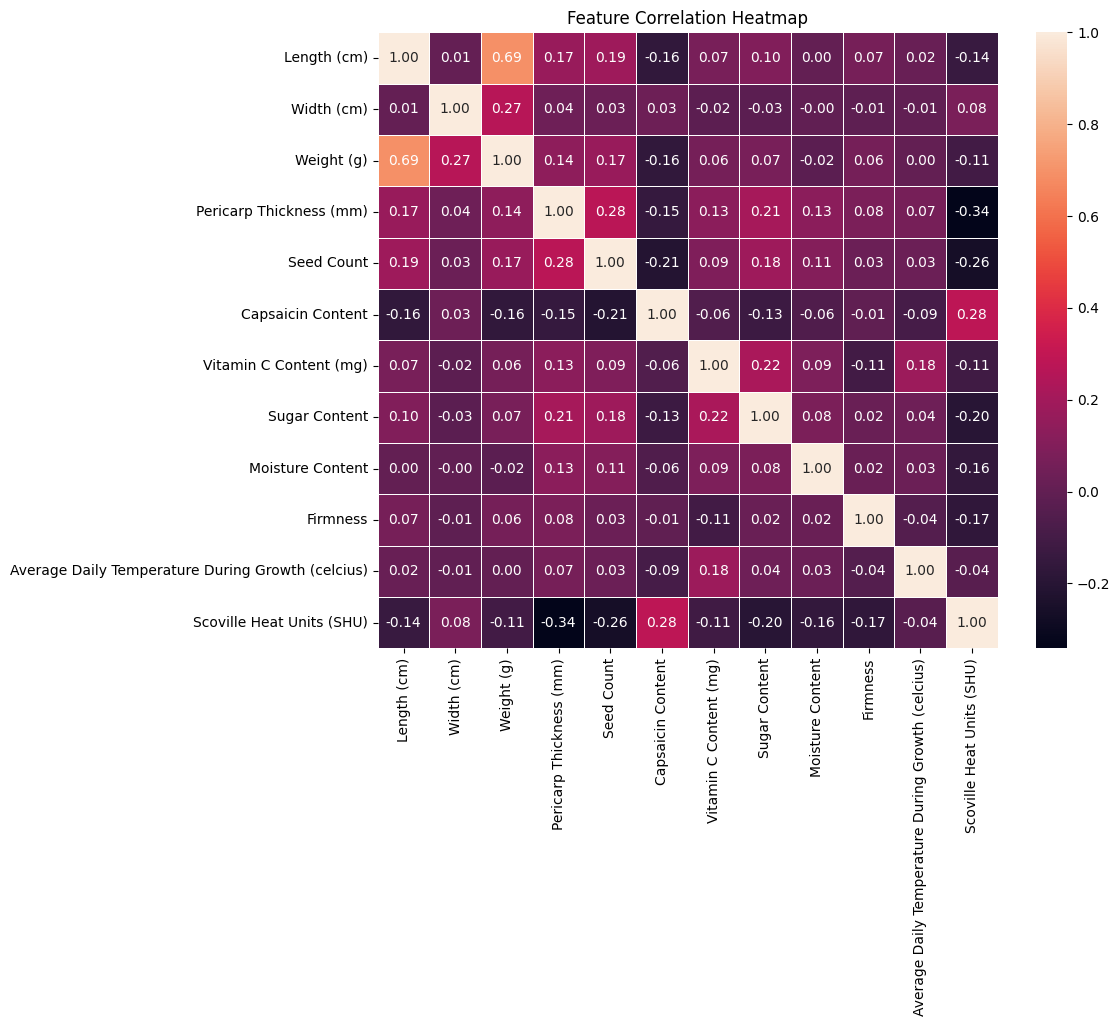

In [8]:
# Numerical columns
numerical_data = train_data.select_dtypes(include=['number'])

# Heatmap of feature correlations
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_data.corr(), annot=True, fmt=".2f", cmap="rocket", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

Not a lot of correlation, except from a noticable positive correlation at 0.69 between Weight an Length, which isn't suprising.

### Visualize feature relationships with pairplot 

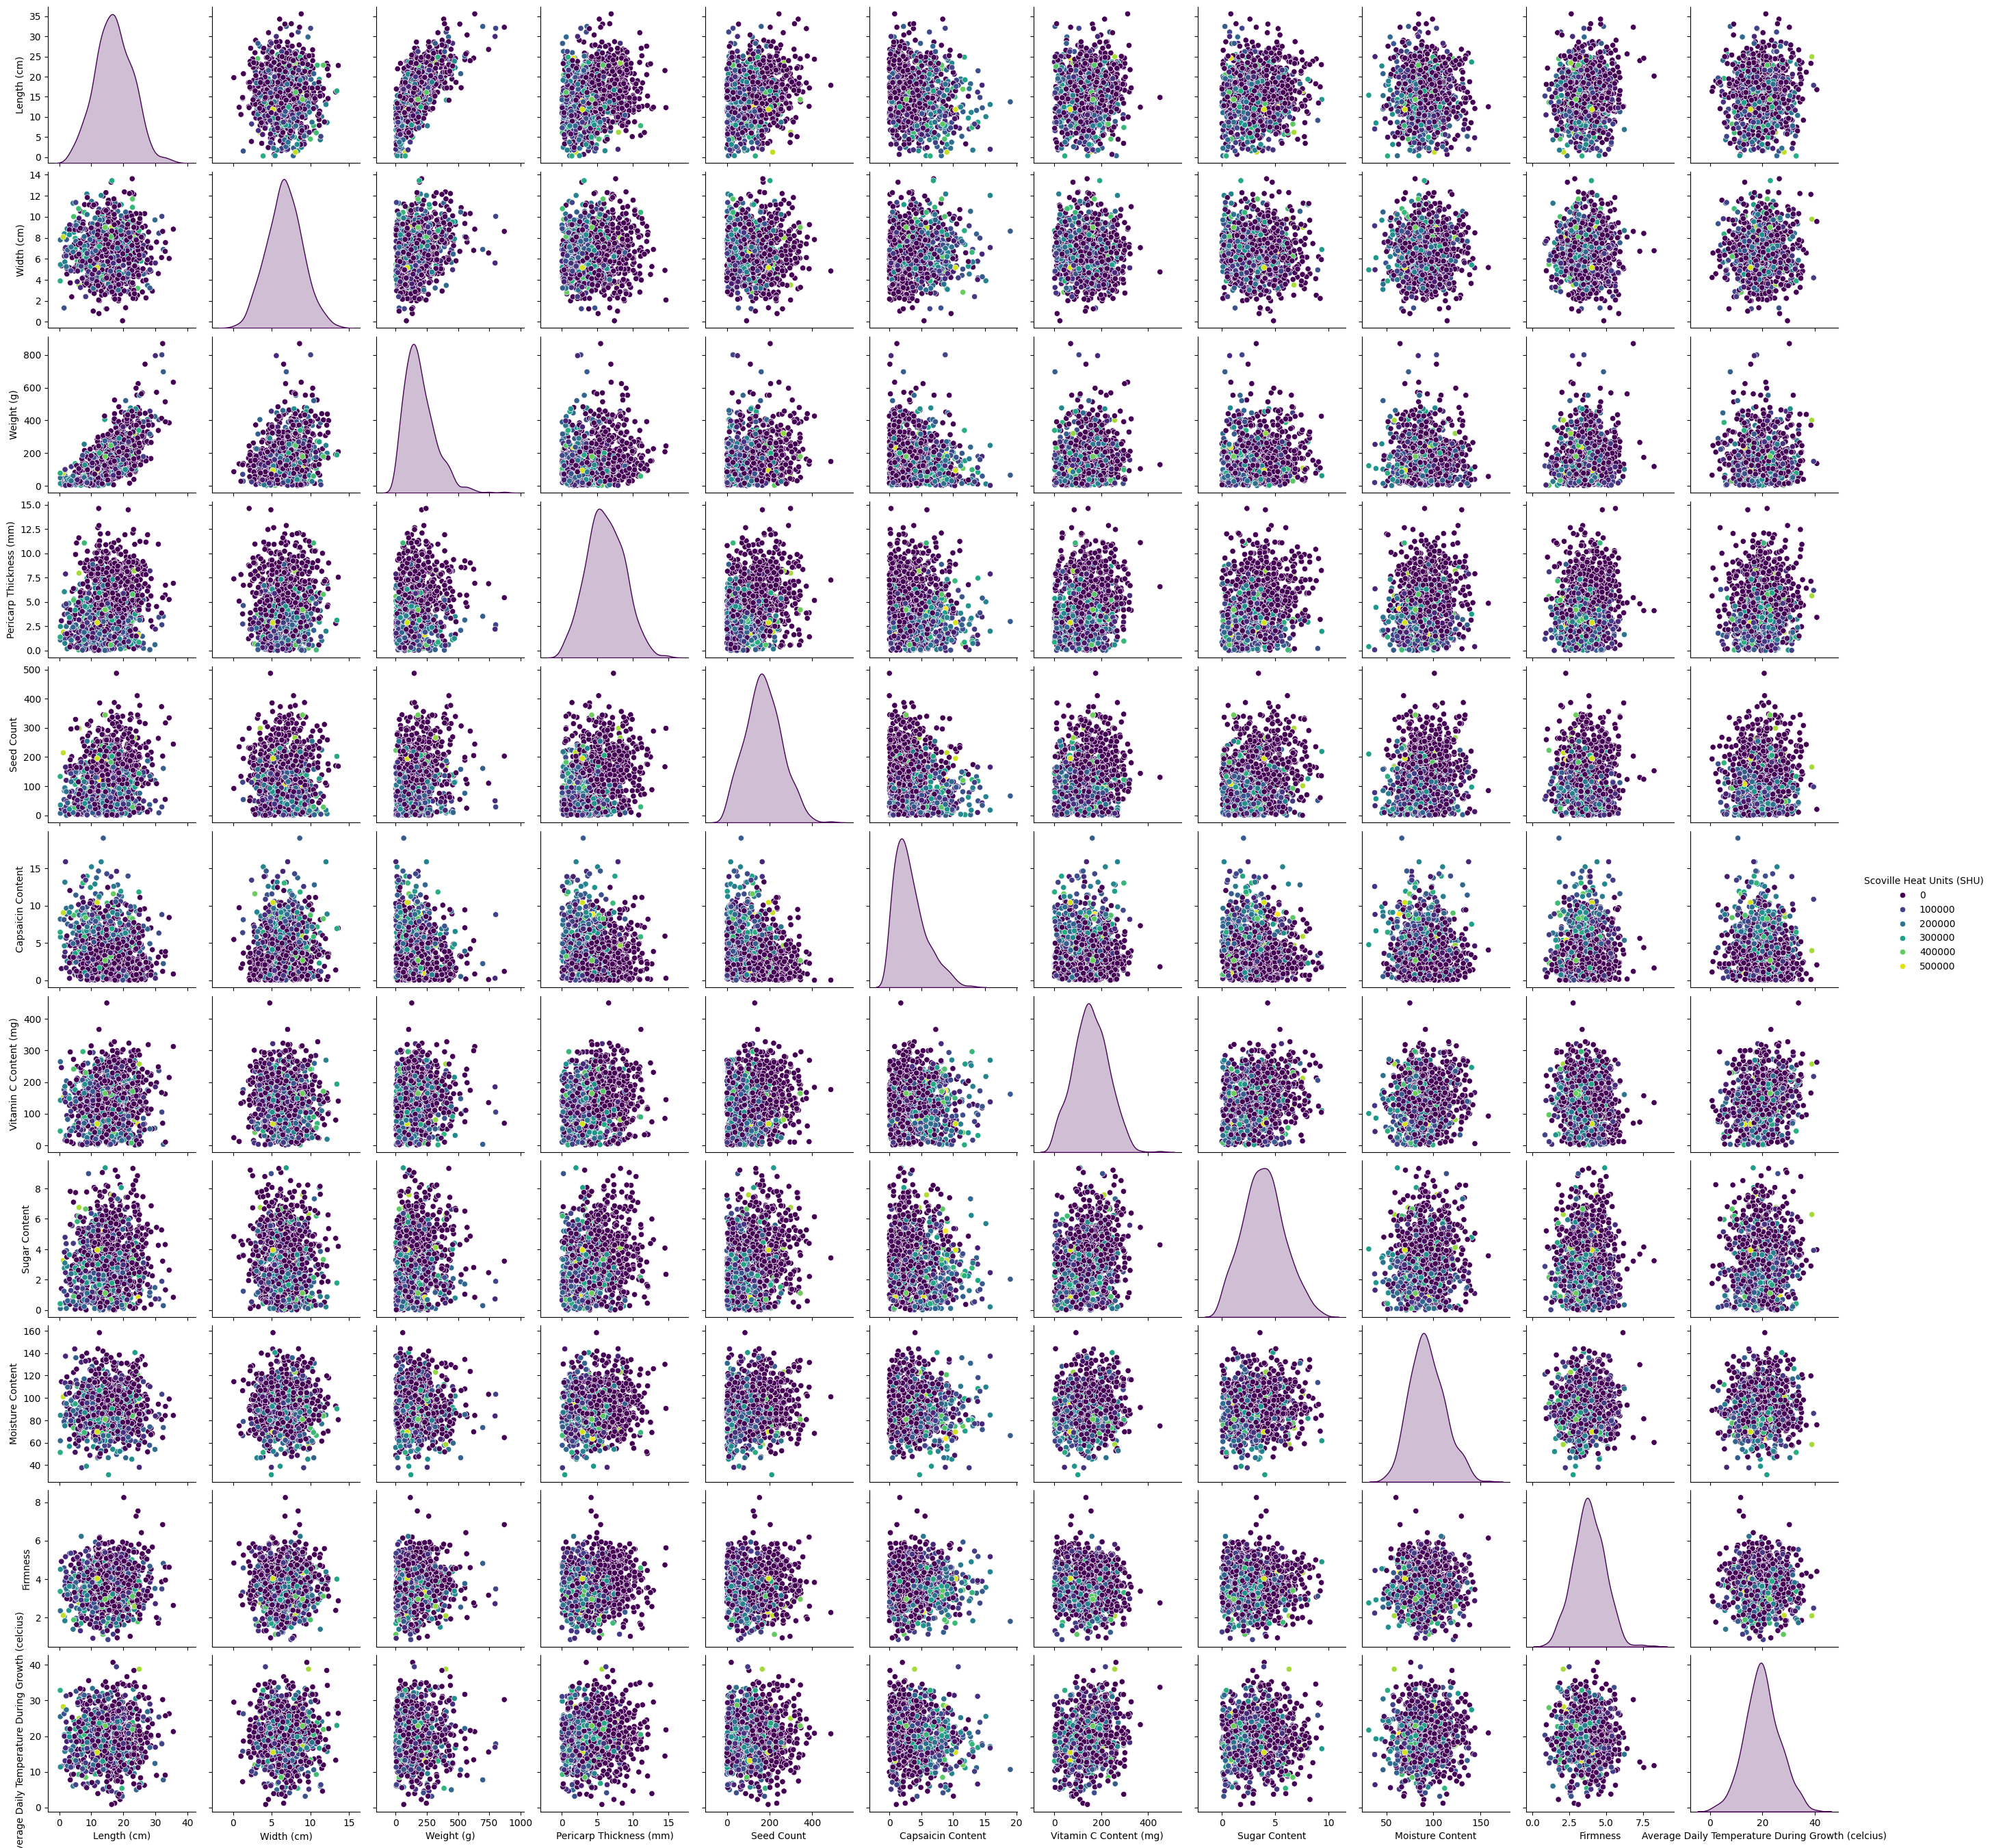

In [9]:
sns.pairplot(train_data, hue='Scoville Heat Units (SHU)', palette='viridis')
plt.show()

The pairplot above show how the different features relate to each other. Hard to see a clear pattern here.

## Data Cleaning

### Look for missing values 

In [10]:
NaN = train_data.isna().sum()
NaN

Length (cm)                                            1
Width (cm)                                             1
Weight (g)                                             1
Pericarp Thickness (mm)                                2
Seed Count                                             1
Capsaicin Content                                      1
Vitamin C Content (mg)                                 0
Sugar Content                                          1
Moisture Content                                       0
Firmness                                               1
color                                                  1
Harvest Time                                           0
Average Daily Temperature During Growth (celcius)      0
Average Temperature During Storage (celcius)         648
Scoville Heat Units (SHU)                              0
dtype: int64

There are missing values in several columns. The most remarkable is 'Average Temperature During Storage (celcius)'. 
Because of the big number of missing values, all these samples cannot be removed. 
We have two options: removing the feature or impute another value. 
The feature will be removed, since 65% of the data set misses this value. 

Rows with missing samples from other features will be removed from the data set. 

### Handle missing values 

In [11]:
# remove the feature 'Average Temperature During Storage (celcius)'
train_data = train_data.drop(columns=['Average Temperature During Storage (celcius)'])
test_data = test_data.drop(columns=['Average Temperature During Storage (celcius)'])

# remove rows with missing values in other features 
train_data.dropna(inplace=True) 

# check if there are any missing values left
train_data.isna().sum()

Length (cm)                                          0
Width (cm)                                           0
Weight (g)                                           0
Pericarp Thickness (mm)                              0
Seed Count                                           0
Capsaicin Content                                    0
Vitamin C Content (mg)                               0
Sugar Content                                        0
Moisture Content                                     0
Firmness                                             0
color                                                0
Harvest Time                                         0
Average Daily Temperature During Growth (celcius)    0
Scoville Heat Units (SHU)                            0
dtype: int64

In [12]:
train_data.head()

,Length (cm),Width (cm),Weight (g),Pericarp Thickness (mm),Seed Count,Capsaicin Content,Vitamin C Content (mg),Sugar Content,Moisture Content,Firmness,color,Harvest Time,Average Daily Temperature During Growth (celcius),Scoville Heat Units (SHU)
0,17.37,5.42,94.30,4.90,193.93,3.21,173.59,6.15,88.59,3.40,red,Midday,8.68,0.00
1,27.78,4.75,262.71,6.56,186.29,8.19,100.41,2.36,111.20,5.45,green,Midday,22.44,0.00
2,6.17,3.51,66.72,7.96,298.81,4.69,125.91,6.75,72.98,2.77,red,Midday,24.99,455995.06
3,6.12,6.07,51.24,4.57,39.36,2.76,143.54,5.93,63.93,1.62,yellow,Midday,13.05,0.00
4,28.58,4.84,166.51,3.07,194.07,7.01,193.76,2.85,88.19,3.99,red,Midday,27.08,0.00


In [13]:
train_data.shape 

(990, 14)

The removal of missing values, and imputation of 'Unknown' in the 'Average Temperature During Storage (celcius)' column was successful. 

The new data set has 990 samples, ten samples were removed. 

### Transform categorical variables using OneHotEncoder 

The data set has two categorical features: 
- Color 
- Harvest time

These will be converted into numerical values using OneHotEncoder from Scikit-learn. 

In [14]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore') 

encoded = ohe.fit_transform(train_data[['color', 'Harvest Time']])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['color', 'Harvest Time']))

# concatenate the encoded features with the original dataframe 
train_data_enc = pd.concat([train_data, encoded_df], axis=1) 

# drop the original categorical columns
train_data_enc.drop(columns=['color', 'Harvest Time'], inplace=True)

The code below shows the new feature names: 

In [15]:
train_data_enc.columns

Index(['Length (cm)', 'Width (cm)', 'Weight (g)', 'Pericarp Thickness (mm)',
       'Seed Count', 'Capsaicin Content', 'Vitamin C Content (mg)',
       'Sugar Content', 'Moisture Content', 'Firmness',
       'Average Daily Temperature During Growth (celcius)',
       'Scoville Heat Units (SHU)', 'color_green', 'color_red', 'color_yellow',
       'Harvest Time_Evening', 'Harvest Time_Midday', 'Harvest Time_Morning'],
      dtype='object')

#### Repeat for the test data 

In [16]:
encoded_test = ohe.transform(test_data[['color', 'Harvest Time']])
encoded_test_df = pd.DataFrame(encoded_test, columns=ohe.get_feature_names_out(['color', 'Harvest Time'])) 

# concatenate the encoded features with the original dataframe 
test_data_enc = pd.concat([test_data, encoded_test_df], axis=1) 

# drop the original categorical columns
test_data_enc.drop(columns=['color', 'Harvest Time'], inplace=True)

In [17]:
test_data_enc.columns

Index(['Length (cm)', 'Width (cm)', 'Weight (g)', 'Pericarp Thickness (mm)',
       'Seed Count', 'Capsaicin Content', 'Vitamin C Content (mg)',
       'Sugar Content', 'Moisture Content', 'Firmness',
       'Average Daily Temperature During Growth (celcius)', 'color_green',
       'color_red', 'color_yellow', 'Harvest Time_Evening',
       'Harvest Time_Midday', 'Harvest Time_Morning'],
      dtype='object')

### Remove outliers from the training data using Z-score 

In [18]:
# compute Z-scores
z_scores = (train_data_enc - train_data_enc.mean()) / train_data_enc.std()

# identify Outliers (absolute Z-score > 3)
outliers = z_scores.abs() > 3

# count total outliers
num_outliers = outliers.sum().sum() # Summing over all columns

print(f"Total number of outliers: {num_outliers}")


Total number of outliers: 62


In [19]:
# remove the detected outliers 
train_data_clean = train_data_enc[~outliers.any(axis=1)]
train_data_clean.shape

(940, 18)

After removing missing values, the feature 'Temperature during storage (celcius)' and outliers, our training data now contains 18 columns and 940 samples. 

## Data Preprocessing and Visualization 

### Split the training data into X_train and y_train 

In [20]:
X_train = train_data_clean.drop(columns=['Scoville Heat Units (SHU)']) 
y_train = train_data_clean['Scoville Heat Units (SHU)']
X_train.shape, y_train.shape

((940, 17), (940,))

In [21]:
y_train.isna().sum()

np.int64(10)

In [22]:
y_train = y_train.dropna()
X_train = X_train.loc[y_train.index]

10 samples in y_train was defined with missing values in y_train, these where therefore removed from the data set. 

In [23]:
y_train.shape, X_train.shape

((930,), (930, 17))

### Visualize the features in X_train (cleaned data) 

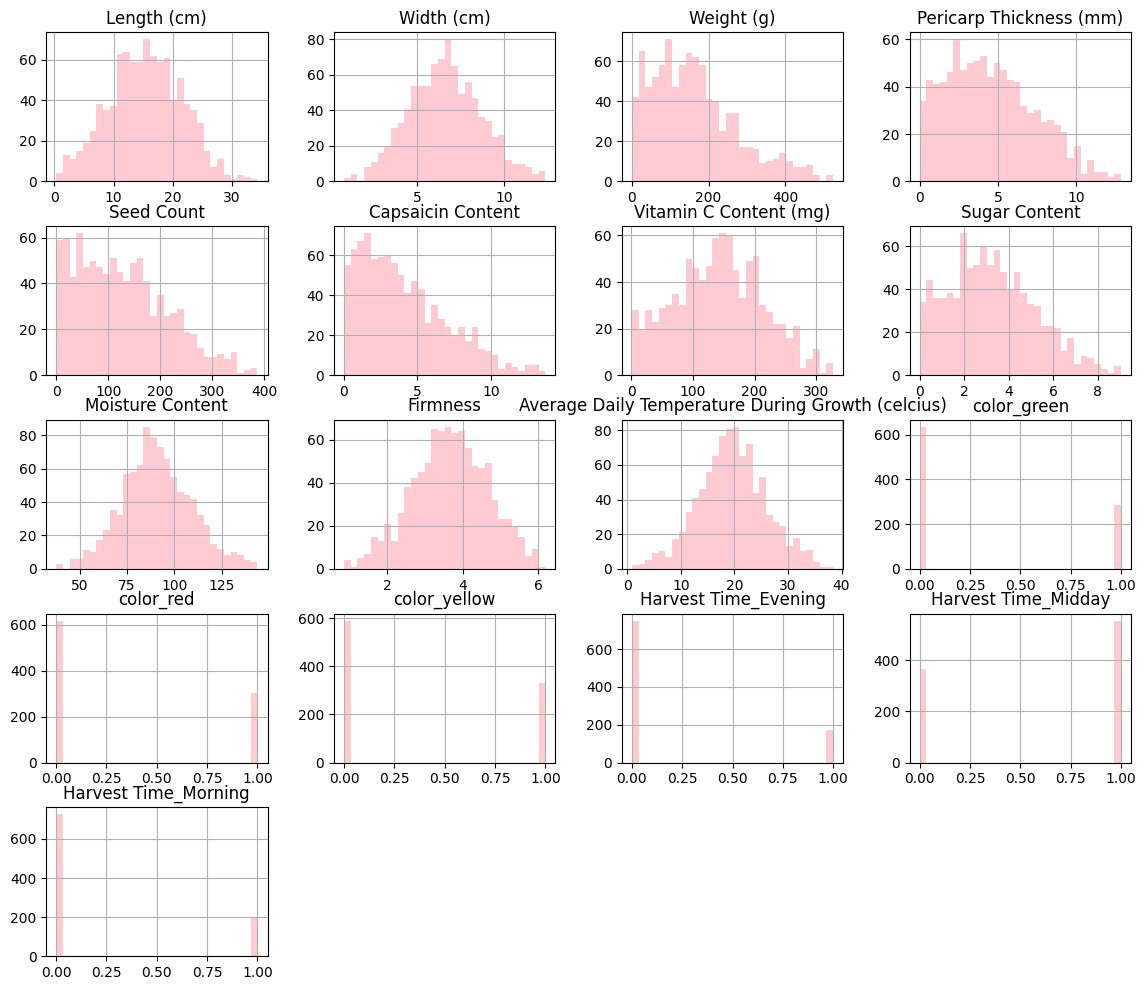

In [24]:
histogram = X_train.hist(figsize=(14, 12), bins=30, color='lightpink', alpha=0.7)

Most features looks quite normally distributed, except the encoded binary features (either 0 or 1). 

### Visualize the unscaled data (X_train)

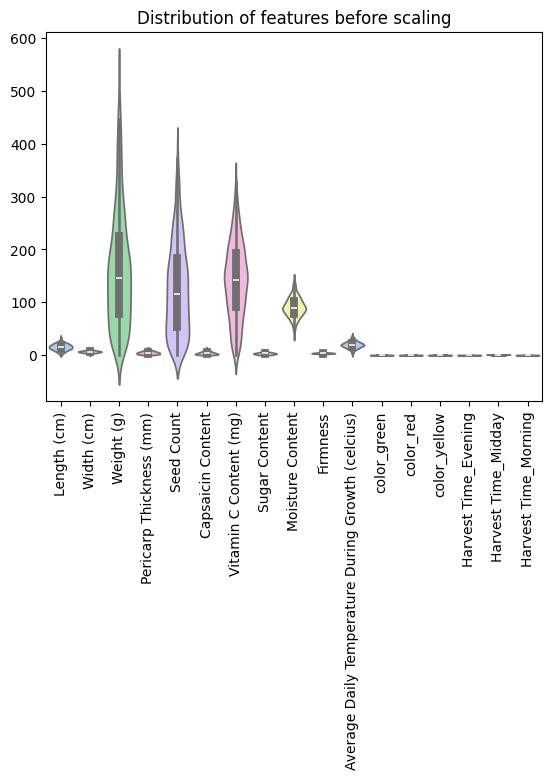

In [25]:
sns.violinplot(X_train, palette = sns.color_palette('pastel', n_colors= X_train.shape[1])) 
plt.xticks(rotation = 90)
plt.title('Distribution of features before scaling')
plt.show()

The features are unevenly distributed and should be scaled. For example, Weight and Seed Count have much higher values than the binary feature 'color'.

### Visualize target distribution 

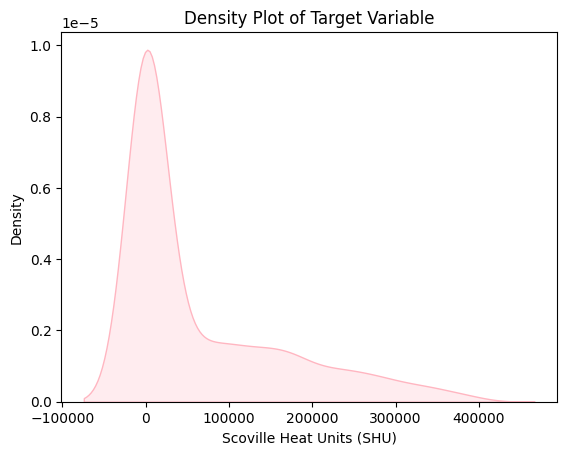

In [26]:
sns.kdeplot(y_train, fill=True, color='lightpink')
plt.title("Density Plot of Target Variable")
plt.xlabel("Scoville Heat Units (SHU)")
plt.show()

In the plot above we can see how the target variable is distributed for the samples in the training set. 

## Modelling

### A) Regression analysis

#### Random forest regression 

In [27]:
# define the random forest regression pipeline 
pipe_rf = make_pipeline(
    SimpleImputer(strategy = 'median'),
    StandardScaler(),
    RandomForestRegressor())

pipe_rf

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('randomforestregressor', RandomForestRegressor())])

In [28]:
# get the parameters of the pipeline 
pipe_rf.get_params()

{'memory': None,
 'steps': [('simpleimputer', SimpleImputer(strategy='median')),
  ('standardscaler', StandardScaler()),
  ('randomforestregressor', RandomForestRegressor())],
 'transform_input': None,
 'verbose': False,
 'simpleimputer': SimpleImputer(strategy='median'),
 'standardscaler': StandardScaler(),
 'randomforestregressor': RandomForestRegressor(),
 'simpleimputer__add_indicator': False,
 'simpleimputer__copy': True,
 'simpleimputer__fill_value': None,
 'simpleimputer__keep_empty_features': False,
 'simpleimputer__missing_values': nan,
 'simpleimputer__strategy': 'median',
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'randomforestregressor__bootstrap': True,
 'randomforestregressor__ccp_alpha': 0.0,
 'randomforestregressor__criterion': 'squared_error',
 'randomforestregressor__max_depth': None,
 'randomforestregressor__max_features': 1.0,
 'randomforestregressor__max_leaf_nodes': None,
 'randomforestregressor__max_samp

In [29]:
# perform grid search for random forest regression 
gs_rf = GridSearchCV(pipe_rf, 
                     param_grid = {'randomforestregressor__n_estimators': [100,200], 
                                   'randomforestregressor__max_depth': [None, 20],
                                   'randomforestregressor__min_samples_split': [2, 5, 10], 
                                   'randomforestregressor__max_features': ['sqrt']},
                     cv = 5, 
                     scoring = 'neg_mean_absolute_error')

# fit the model 
gs_rf.fit(X_train, y_train)

# print the best parameters and score 
print(f'The best model parameters are: {gs_rf.best_params_}') 
print(f'The best negative mean error score is: {-gs_rf.best_score_}') 

best_model_rf = gs_rf.best_estimator_

The best model parameters are: {'randomforestregressor__max_depth': 20, 'randomforestregressor__max_features': 'sqrt', 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 200}
The best negative mean error score is: 59598.261646339975


The classifier found to have the best performance on the data set in task A, was the Random Forest Regressor. 

The model hyperparameters was tuned using GridSearchCV with 5-fold cross-validation. 

The best model parameters are displayed in the output above. 

### B) Multi-class classification analysis with an ensemble classifier

Binning the target values was not found efficient during our testing, as the accuracy dropped exponentially with increasing number of bins.

### C) A two step analysis 

#### Convert target variable to a binary variable 

In [30]:
# convert the target variable to binary classification (0 or 1)
y_binary = (y_train > 0).astype(int)
print(y_binary.head(6))

# 1 is hot peppers 
# 0 is not hot peppers 

0    0
1    0
3    0
4    0
5    0
6    1
Name: Scoville Heat Units (SHU), dtype: int64


#### Train a Random Forest Classifier on the new target 

In [31]:
# define the pipeline 
pipe_rfc = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    RandomForestClassifier())

# perform grid search for random forest classifier 
gs_rfc = GridSearchCV(pipe_rfc, 
                       param_grid={'randomforestclassifier__n_estimators': [100, 200], 
                                   'randomforestclassifier__max_depth': [None, 20],
                                   'randomforestclassifier__min_samples_split': [2, 5, 10], 
                                   'randomforestclassifier__max_features': ['sqrt']},
                       cv=5, 
                       scoring='accuracy', 
                       n_jobs=-1)

# fit the model 
gs_rfc.fit(X_train, y_binary) 

# print the best parameters and score
print(f'The best model parameters are: {gs_rfc.best_params_}')
print(f'The best accuracy score is: {gs_rfc.best_score_}')

best_model_rfc = gs_rfc.best_estimator_ 

The best model parameters are: {'randomforestclassifier__max_depth': None, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 200}
The best accuracy score is: 0.8849462365591398


#### Predict spicy (1) versus non spicy (0) on the test set 

In [32]:
is_spicy = best_model_rfc.predict(test_data_enc)  

#### Create a regression model to estimate the SHU score for the spicy peppers 

In [37]:
# train regression model on the spicy samples from the training set 
spicy_train = y_binary == 1 
X_train_spicy = X_train[spicy_train]
y_train_spicy = y_train[spicy_train]

# define the random forest regressor pipeline 
pipe_rf_reg = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    RandomForestRegressor())

# perform grid search for random forest regressor
gs_rf_reg = GridSearchCV(pipe_rf_reg, 
                          param_grid={'randomforestregressor__n_estimators': [100, 200], 
                                      'randomforestregressor__max_depth': [None, 20],
                                      'randomforestregressor__min_samples_split': [2, 5, 10], 
                                      'randomforestregressor__max_features': ['sqrt']},
                          cv=5, 
                          scoring='neg_mean_absolute_error', 
                          n_jobs=-1)

# fit the model
gs_rf_reg.fit(X_train_spicy, np.log1p(y_train_spicy)) 

print(f'The best model parameters are: {gs_rf_reg.best_params_}')
print(f'The best negative mean error score is: {-gs_rf_reg.best_score_}')

best_model_rf_reg = gs_rf_reg.best_estimator_

The best model parameters are: {'randomforestregressor__max_depth': None, 'randomforestregressor__max_features': 'sqrt', 'randomforestregressor__min_samples_split': 10, 'randomforestregressor__n_estimators': 100}
The best negative mean error score is: 0.8029017265284786


Since the distribution of SHU is quite skewed, y was log-transformed before fitting. Therefore the MAE score obtained from the Grid Search is also log-transformed, the actual MAE score can be seen in Kaggle.

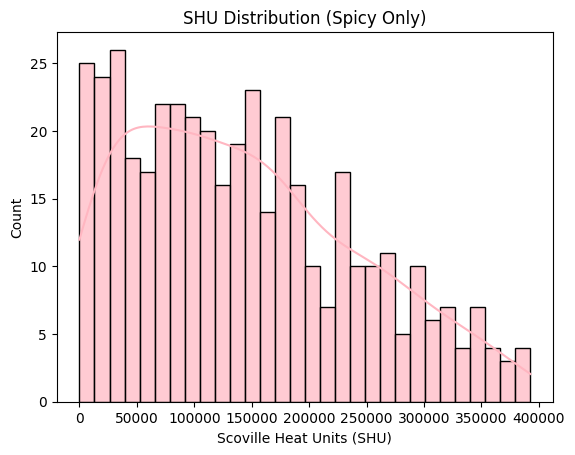

In [34]:
sns.histplot(y_train_spicy, kde = True, bins=30, color='lightpink', alpha=0.7)
plt.title("SHU Distribution (Spicy Only)")
plt.show()

Task C gave us the best performing model, where a Random Forest Classifier first was trained to predict the new target of not spicy (0) and spicy (1) peppers. The best model parameters were: 
- 'randomforestclassifier__max_depth': None
- 'randomforestclassifier__max_features': 'sqrt'
- 'randomforestclassifier__min_samples_split': 5
- 'randomforestclassifier__n_estimators': 200

Then a Random Forest Regressor was used to predict the SHU value of the spciy peppers. The best parameters found were:
- 'randomforestregressor__max_depth': 20
- 'randomforestregressor__max_features': 'sqrt'
- 'randomforestregressor__min_samples_split': 2 
- 'randomforestregressor__n_estimators': 200

#### Predict the SHU score for the test data and submit to Kaggle

In [35]:
# create empty array for SHU predictions
full_pred_array = np.zeros(len(test_data_enc))

# predict SHU (log scale) for only the spicy samples
spicy_indices = np.where(is_spicy == 1)[0]
spicy_test_data = test_data_enc.iloc[spicy_indices]

log_shu_pred = best_model_rf_reg.predict(spicy_test_data)
shu_pred = np.expm1(log_shu_pred) # take the inverse of np.log1p

# fill the predicted SHU for spicy samples
full_pred_array[spicy_indices] = shu_pred

# format into DataFrame
pred = pd.DataFrame(full_pred_array, columns=['Scoville Heat Units (SHU)'])
pred.index = test_data_enc.index
pred.index.name = "index"
pred.to_csv('submission.csv', index=True)